
Bias - Variance trade-off

Underfitting and Overfitting

# Setup

In [4]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Polynomial Regression: overfitting and underfitting

In [2]:
# Let's create a new dataset
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

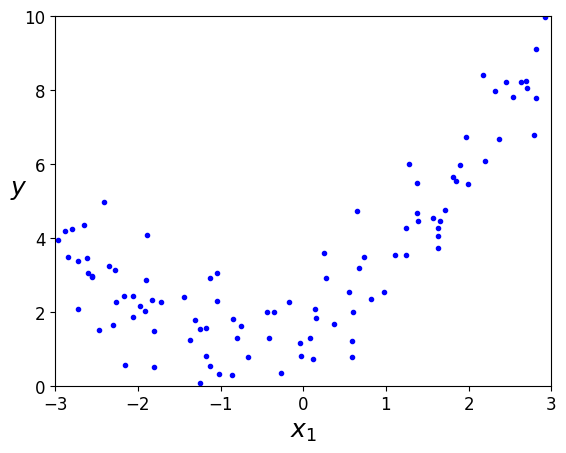

In [5]:
# Plot the data
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
# save_fig("quadratic_data_plot")
plt.show()

In [6]:
# Fit a LR model to the data
from sklearn.linear_model import LinearRegression
# Your code here
lin_reg = LinearRegression()
lin_reg.fit(X, y)

LinearRegression()

In [7]:
# Print the learned coefficients
lin_reg.intercept_, lin_reg.coef_

(array([3.56401543]), array([[0.84362064]]))

In [8]:
# Fit the following models on the training data and report the error obtained (in the training data) for each model:
# You can use the mean_squared_error function from sklearn.metrics
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

# Model 1: Y = b0 + b1X + e
lin_reg = LinearRegression()
lin_reg.fit(X, y)
m1_y_pred = lin_reg.predict(X)
m1_mse = mean_squared_error(y, m1_y_pred)
print(m1_mse)

# Model 2: Y = b0 + b1X + b2X^2 + e
m2_poly = PolynomialFeatures(degree=2, include_bias=False)
m2_X = m2_poly.fit_transform(X)
m2 = LinearRegression()
m2.fit(m2_X, y)
m2_y_pred = m2.predict(m2_X)
m2_mse = mean_squared_error(y, m2_y_pred)
print(m2_mse)

# Model 100: Y = b0 + b1X + b2X^2 + ... + b100X^100 + e
m100_poly = PolynomialFeatures(degree=25, include_bias=False)
m100_X = m100_poly.fit_transform(X)
m100 = LinearRegression()
m100.fit(m100_X, y)
m100_y_pred = m100.predict(m100_X)
m100_mse = mean_squared_error(y, m100_y_pred)
print(m100_mse)

# For model 1, you can use the LinearRegression function directly
# For model 2 and 100, you first need to extend the data: manually or with PolynomialFeatures()

3.0245639566396174
0.7771936663502366
0.6567858000042304


In [9]:
# Report the MSE of each model on the training data
print(m1_mse)
print(m2_mse)
print(m100_mse)

3.0245639566396174
0.7771936663502366
0.6567858000042304


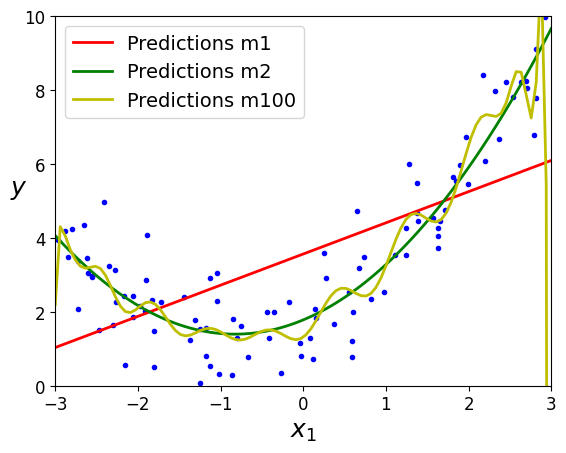

In [10]:
# Make a plot with the training data and the predictions obtained by each model, what do you observe?
X_new=np.linspace(-3, 3, 100).reshape(100, 1)
m1_y_pred = lin_reg.predict(X_new)
m2_X = m2_poly.fit_transform(X_new)
m2_y_pred = m2.predict(m2_X)
m100_X = m100_poly.fit_transform(X_new)
m100_y_pred = m100.predict(m100_X)

plt.plot(X, y, "b.")
plt.plot(X_new, m1_y_pred, "r-", linewidth=2, label="Predictions m1")
plt.plot(X_new, m2_y_pred, "g-", linewidth=2, label="Predictions m2")
plt.plot(X_new, m100_y_pred,"y-", linewidth=2, label="Predictions m100")

plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([-3, 3, 0, 10])
plt.show()

In [14]:
# Generate 10000 additional data points and use them to test the models, what do you observe?
m = 10000
Xtest = 6 * np.random.rand(m, 1) - 3
ytest = 0.5 * Xtest**2 + Xtest + 2 + np.random.randn(m, 1)

m1_y_pred = lin_reg.predict(Xtest)
m1_mse = mean_squared_error(ytest, m1_y_pred)
print(m1_mse)

# Model 2: Y = b0 + b1X + b2X^2 + e
m2_X = m2_poly.fit_transform(Xtest)
m2_y_pred = m2.predict(m2_X)
m2_mse = mean_squared_error(ytest, m2_y_pred)
print(m2_mse)

# Model 100: Y = b0 + b1X + b2X^2 + ... + b100X^100 + e
m100_X = m100_poly.fit_transform(Xtest)
m100_y_pred = m100.predict(m100_X)
m100_mse = mean_squared_error(ytest, m100_y_pred)
print(m100_mse)

2.8603207959107975
1.0460868523570606
14.015429646604272
